In [ ]:
%pip install -q rasterio geopandas torch torchvision numpy scikit-image matplotlib tqdm

In [ ]:
# Only required with Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import glob
import numpy as np
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import torch
from torch.utils.data import Dataset, DataLoader
import string

# Dataset

In [3]:
#@title Constants
BANDS = [1, 2, 3, 4, 5]   # Blue, Green, Red, RedEdge, NIR

In [25]:
#@title Inputs
MULTISPEC_IMAGE_PATH = "../dataset/EscaYard/tif/20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO.tif" # @param {type:"string"}
# BOYTRIS_CLUSTERS_SHP   = "../dataset/Vineyard_Disease_Pontevedra/Botrytis_clusters/Botrytis_clusters.shp" # @param {type:"string"}
# GCP_SHP = "../dataset/Vineyard_Disease_Pontevedra/GCPs/GCPs.shp" # @param {type:"string"}
TRUNK_LOCATIONS_SHP = "../dataset/EscaYard/trunk_locations/trunk_locations_VineyardB7.shp" # @param {type:"string"}
OUTPUT_DIR = "../output/EscaYard/" # @param {type:"string"}

In [5]:
#@title parameters
PATCH_SIZE = 128 # @param {type:"number"}
VAL_SPLIT = 0.2

In [8]:
# # Optional GPU support
# try:
#     import cupy as cp
#     xp = cp
#     GPU_AVAILABLE = True
#     print("✅ Using GPU via CuPy")
# except ImportError:
#     xp = np
#     GPU_AVAILABLE = False
#     print("⚠️ CuPy not available, using CPU NumPy")

In [29]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.transform import Affine
# from rasterio.control import GroundControlPoint
import os


def compute_affine_from_gcps(gcp_shp_path, img_width, img_height):
    """
    Compute an affine transform between approximate pixel coordinates
    (col, row) and real-world coordinates (X, Y) using least squares.
    """
    gdf = gpd.read_file(gcp_shp_path)
    if gdf.crs is None:
        gdf.set_crs("EPSG:25829", inplace=True)

    # Sort by ID to make mapping reproducible
    gdf = gdf.sort_values(by="id").reset_index(drop=True)

    n = len(gdf)
    if n < 3:
        raise ValueError("Need at least 3 GCPs to estimate affine transform.")

    # --- Step 1. Assign approximate pixel grid positions ---
    # Assume GCPs roughly distributed across image area
    cols = np.linspace(0, img_width, n)
    rows = np.linspace(0, img_height, n)
    cols = np.clip(cols, 0, img_width - 1)
    rows = np.clip(rows, 0, img_height - 1)

    # --- Step 2. Fit least squares affine transform ---
    A = []
    bx = []
    by = []
    for i in range(n):
        A.append([cols[i], rows[i], 1, 0, 0, 0])
        A.append([0, 0, 0, cols[i], rows[i], 1])
        bx.append(gdf.geometry[i].x)
        by.append(gdf.geometry[i].y)

    A = np.array(A)
    b = np.array(bx + by)
    params, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c, d, e, f = params
    affine = Affine(a, b_, c, d, e, f)

    print(affine)
    return affine, gdf.crs


def load_multispectral_image(path_prefix, gcp_shp_path=None):
    """
    Load and stack bands from a single large multiband TIFF (preferred) or a directory
    of per-band TIFFs. Do NOT perform any CRS alignment here — files already contain everything.
    Returns stacked (B, H, W) float32 and meta dict (rasterio meta).
    """
    bands_data = []
    meta = None

    # If path_prefix is a file, open it and read the requested bands
    if os.path.exists(path_prefix) and os.path.isfile(path_prefix):
        with rasterio.open(path_prefix) as src:
            meta = src.meta.copy()
            # read all bands available (or limit to BANDS present in file)
            available = src.count
            read_bands = [b for b in BANDS if 1 <= b <= available]
            if not read_bands:
                raise RuntimeError(f"No requested bands {BANDS} available in {path_prefix} (count={available})")
            for b in read_bands:
                bands_data.append(src.read(b).astype(np.float32))
    else:
        # fallback: treat path_prefix as directory/prefix and try per-band files
        # try prefix + "_<b>.tif"
        paths = [f"{path_prefix}_{b}.tif" for b in BANDS]
        found = False
        for p in paths:
            if os.path.exists(p):
                found = True
                with rasterio.open(p) as src:
                    if meta is None:
                        meta = src.meta.copy()
                    bands_data.append(src.read(1).astype(np.float32))
        if not found:
            # try find any .tif inside directory
            tif_list = sorted(glob.glob(os.path.join(path_prefix, "*.tif")))
            if tif_list:
                # if a single multiband tif found inside directory, use first
                with rasterio.open(tif_list[0]) as src:
                    meta = src.meta.copy()
                    for b in range(1, min(src.count, max(BANDS)) + 1):
                        bands_data.append(src.read(b).astype(np.float32))
            else:
                raise FileNotFoundError(f"No TIFF file found at '{path_prefix}' nor matching band files.")

    stacked = np.stack(bands_data, axis=0).astype(np.float32)  # (B, H, W)

    # Do not modify CRS/transform here. If GCPs requested, caller may compute externally.
    return stacked, meta

# Vegetation indices
def compute_ndvi(stacked):
    """Compute NDVI from multispectral bands (assumes RedEdge sensor order)."""
    nir = stacked[3]
    red = stacked[2]
    ndvi = (nir - red) / (nir + red + 1e-6)
    return np.clip(ndvi, -1, 1)

def compute_ndre(stacked):
    red_edge = stacked[4]
    nir = stacked[3]
    ndre = (nir - red_edge) / (nir + red_edge + 1e-6)
    return np.clip(ndre, -1, 1)


# Align shapefiles
def load_and_align_shapefile(path, reference_meta):
    """Reproject shapefile to the raster CRS."""
    gdf = gpd.read_file(path)
    if gdf.crs != reference_meta['crs']:
        gdf = gdf.to_crs(reference_meta['crs'])
    return gdf

def rasterize_shapes(shapefile, reference_raster):
    """Rasterizes shapefile polygons to match raster grid."""
    import rasterio.features
    with rasterio.open(reference_raster) as src:
        meta = src.meta.copy()
        transform = src.transform
        out_shape = (src.height, src.width)

    gdf = gpd.read_file(shapefile).to_crs(meta['crs'])
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.uint8
    )
    return mask

# Patch extraction
def extract_patches(image, patch_size=PATCH_SIZE):
    patches = []
    h, w = image.shape[1], image.shape[2]
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = image[:, y:y+patch_size, x:x+patch_size]
            if patch.shape[1] == patch_size and patch.shape[2] == patch_size:
                patches.append(patch)
    return np.stack(patches)

In [20]:
stacked, meta = load_multispectral_image(path_prefix="/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/EscaYard/20220714_FLEXIGROBOTS_B9_30M0G_MS_PRO.tif")

print("Stack shape:", stacked.shape)
print("CRS:", meta.get("crs"))
print("Transform:", meta.get("transform"))

/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/EscaYard/20220714_FLEXIGROBOTS_B9_30M0G_MS_PRO.tif


: 

# Dataset Class - Vineyard Dataset

In [37]:
#@title Dataset Class - (lazy memory-mapped, huge TIF and multi-TIF support)
from rasterio.windows import Window
from rasterio.enums import Resampling
import re, glob, os
import numpy as np
import torch
import geopandas as gpd
from torch.utils.data import Dataset

class VineyardDataset(Dataset):
    def __init__(self, data_dir, shapefiles=None, patch_size=128, stride=128, bands=[1,2,3,4,5], gcp_shp_path=None):
        """
        Supports:
          - data_dir: path to a single large multiband TIFF file
          - or a directory containing multiple large TIFF files (each a scene)
          - or per-band TIFFs (prefix_band.tif pattern)

        This implementation lazily reads patches via rasterio windows — no full loading.
        It builds an index of (file, x, y) patch coordinates across all TIFFs.
        """
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.stride = stride
        self.bands = bands
        self.gcp_shp_path = gcp_shp_path

        self.tif_files = []
        self.prefixes = []

        # Detect whether it's a single file or directory of tifs
        if os.path.isfile(data_dir) and data_dir.lower().endswith(".tif"):
            self.tif_files = [os.path.abspath(data_dir)]
            self.prefixes = [os.path.splitext(os.path.basename(data_dir))[0]]
        else:
            self.tif_files = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
            if not self.tif_files:
                raise ValueError(f"No TIFF files found in directory: {data_dir}")
            self.prefixes = [os.path.splitext(os.path.basename(fp))[0] for fp in self.tif_files]

        # Load lightweight metadata for each tif (no raster data)
        self.meta_per_file = {}
        for tif_path in self.tif_files:
            with rasterio.open(tif_path) as src:
                meta = src.meta.copy()
                h, w = src.height, src.width
                meta.update(height=h, width=w)
                self.meta_per_file[tif_path] = meta

        # Build index across all TIFFs
        self.index = []
        for tif_path, prefix in zip(self.tif_files, self.prefixes):
            meta = self.meta_per_file[tif_path]
            h, w = meta["height"], meta["width"]
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    self.index.append((tif_path, prefix, x, y))

        # Load shapefiles lazily (assumed aligned with rasters)
        self._loaded_shapefiles = {}
        for key, shp_path in (shapefiles or {}).items():
            if shp_path and os.path.exists(shp_path):
                try:
                    self._loaded_shapefiles[key] = gpd.read_file(shp_path)
                except Exception:
                    self._loaded_shapefiles[key] = None
            else:
                self._loaded_shapefiles[key] = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        tif_path, prefix, x, y = self.index[idx]
        imgs_all_bands = []

        # Read patch from large or multi-tif raster lazily
        try:
            with rasterio.open(tif_path) as src:
                window = Window(x, y, self.patch_size, self.patch_size)
                available = src.count
                for b in self.bands:
                    if b < 1 or b > available:
                        raise RuntimeError(f"Band {b} not available in {prefix} ({available} total)")
                    img = src.read(b, window=window, resampling=Resampling.nearest).astype(np.float32)
                    mn, mx = img.min(), img.max()
                    img = (img - mn) / (mx - mn + 1e-8) if (mx - mn) > 1e-8 else np.zeros_like(img)
                    imgs_all_bands.append(img)
        except Exception as e:
            raise RuntimeError(f"Error reading window ({x},{y}) from {tif_path}: {e}")

        if len(imgs_all_bands) != len(self.bands):
            raise RuntimeError(f"Incomplete band read for {prefix} at ({x},{y})")

        img_input = np.stack(imgs_all_bands[:3], axis=0)  # RGB input

        # NDVI computation
        if len(imgs_all_bands) >= 4:
            red_patch = imgs_all_bands[2]
            nir_patch = imgs_all_bands[3]
            denom = nir_patch + red_patch + 1e-8
            ndvi_patch = np.clip((nir_patch - red_patch) / denom, -1.0, 1.0)
        else:
            ndvi_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)

        target = np.expand_dims(ndvi_patch, axis=0)

        # Placeholder for masks (lazy rasterization per tif)
        masks = {}
        for key, gdf in self._loaded_shapefiles.items():
            if gdf is not None:
                try:
                    from rasterio.features import rasterize
                    with rasterio.open(tif_path) as ref:
                        mask = rasterize(
                            [(geom, 1) for geom in gdf.geometry],
                            out_shape=(ref.height, ref.width),
                            transform=ref.transform,
                            fill=0,
                            dtype=np.uint8
                        )
                        masks[key] = mask[y:y+self.patch_size, x:x+self.patch_size]
                except Exception:
                    masks[key] = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)
            else:
                masks[key] = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)

        botrytis_mask = masks.get('botrytis', np.zeros((self.patch_size, self.patch_size), dtype=np.uint8))
        trunk_mask = masks.get('trunks', np.zeros((self.patch_size, self.patch_size), dtype=np.uint8))
        combined_mask = np.maximum(botrytis_mask, trunk_mask * 2)[np.newaxis, :, :]

        return {
            'image': torch.from_numpy(img_input).float(),
            'target': torch.from_numpy(target).float(),
            'mask': torch.from_numpy(combined_mask).long(),
            'prefix': prefix,
            'coord': (x, y)
        }


In [38]:
BATCH_SIZE = 32
NUM_WORKERS = 0 # Changed to 0 for debugging multiprocessing issue
STRIDE=128
PIN_MEMORY = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True   # automatic mixed precision
CACHE_IN_MEMORY = False  # set True if you have enough RAM and want faster I/O

In [ ]:
from torch.utils.data import DataLoader, random_split
def get_dataloaders(
    batch_size=BATCH_SIZE,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_workers=NUM_WORKERS,
    train_split=0.7,
    val_split=VAL_SPLIT
):
    shapefiles = {
      "trunks": TRUNK_LOCATIONS_SHP
    }
    dataset = VineyardDataset(
        data_dir=MULTISPEC_IMAGE_PATH,
        shapefiles=shapefiles,
        patch_size=patch_size,
        stride=stride,
        gcp_shp_path=None
    )

    total_len = len(dataset)
    train_len = int(total_len * train_split)
    val_len = int(total_len * val_split)
    test_len = total_len - train_len - val_len

    train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

    dataloaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True),
        'val': DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True),
    }

    return dataloaders

loader = get_dataloaders(num_workers=2,val_split=VAL_SPLIT)
if loader is None:
    print("Failed to create dataloaders. Aborting training.")
else:
    print(f"Device: {DEVICE.type}")
    print(f"Train loader batches: {len(loader['train']) if loader['train'] is not None else 0}")
    print(f"Validation loader batches: {len(loader['val']) if loader['val'] is not None else 0}")
    print(f"Test loader batches: {len(loader['test']) if loader['test'] is not None else 0}")

Device: cuda; Train loader batches: 224


# Training

In [40]:
#@title Utility Functions
import numpy as np # Ensure numpy is imported for get_perception_kernels

USE_AMP = True if torch.cuda.is_available() else False

# Helper to create default perception kernels
def get_perception_kernels(device=None, dtype=torch.float32):
    # 3x3 kernels: identity, sobel x, sobel y, laplacian
    id_k = np.array([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]], dtype=np.float32)
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32) / 8.0
    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float32) / 8.0
    lap = np.array([[0, 1, 0],
                    [1, -4, 1],
                    [0, 1, 0]], dtype=np.float32) / 4.0

    kernels = np.stack([id_k, sobel_x, sobel_y, lap], axis=0)  # (K, 3, 3)
    kernels = torch.from_numpy(kernels).to(device=device, dtype=dtype)  # (K, 3, 3)
    return kernels  # (K, 3, 3)


In [41]:
from torch.nn import Module, ReLU, Sequential, Conv2d
from torch.nn.init import zeros_
# Bundle perception mixer + update net into a single module
class PerceptionUpdate(Module):
    """
    TorchScript-friendly module that accepts perception features and produces updates.
    Input: percep map (B, C*K, H, W)
    Output: dx_raw (B, 2*U, H, W) where U = state_channels - input_channels
    """
    def __init__(self, pe_feat:int, hidden_dim:int, U:int):
        super().__init__()
        # pe_feat -> hidden_dim
        self.mix = Conv2d(pe_feat, hidden_dim, kernel_size=1)
        # small MLP => outputs 2*U (delta + gate) so we can apply gating
        self.net = Sequential(
            ReLU(inplace=True),
            Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            ReLU(inplace=True),
            Conv2d(hidden_dim, 2*U, kernel_size=1)  # no bias init required
        )
        # init final layer to near-zero for stability
        with torch.no_grad():
            zeros_(self.net[-1].weight)
            if self.net[-1].bias is not None:
                zeros_(self.net[-1].bias)

    def forward(self, percep):
        x = self.mix(percep)
        return self.net(x)  # (B, 2*U, H, W)

In [42]:
#@title Class Model (ARC-NCA)
# - Maintains a per-cell state: [Input Data (fixed) | hidden channels | NDVI out | alive mask].
#- Uses local perception via a small bank of 3×3 kernels (identity, Sobel X, Sobel Y, Laplacian) applied per channel.
#- Aggregates perception features with a 1×1 conv and passes them through a small MLP (implemented as 1×1 convs) to compute dx (the per-cell update).
# - Applies a stochastic update mask (fire_rate) per step so only a fraction of cells update each iteration (stabilizes training).
# - Clips alive and NDVI channels to keep values stable.
# - Supports iterative rollout (multiple NCA steps).

from torch.nn import Module, ReLU, Sequential, Conv2d, Parameter
from torch.nn.init import zeros_
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

class ARC_NCA(Module):
    """
    ARC-style Neural Cellular Automaton implementation.
    State layout (channel indexing):
      - 0: Input Data - persistent (input_data_channels)
      - Hidden channels: e.g. 16 channels
      - Output channels: e.g. 1 channel (NDVI)
      - Alive channel: 1 channel (mask indicating active cells)
    The model will keep input_data_channels constant (as a conditioning input) and only update hidden, output, and alive channels.
    """

    def __init__(self,
                 input_data_channels: int =3, # Renamed from in_rgb_channels
                 hidden_channels: int =16,
                 out_channels: int =1,  # e.g., NDVI
                 perceive_kernels: torch.Tensor =None,
                 fire_rate: float =0.5,
                 hidden_dim: int =128,
                 use_checkpoint: bool =True,
                 device: torch.device =DEVICE): # Use the global DEVICE constant
        super().__init__()

        # Ensure device is a torch.device object
        self.device = torch.device(device) if isinstance(device, str) else device

        self.input_data_channels = input_data_channels # Renamed
        self.hidden = hidden_channels
        self.out = out_channels
        self.alive = 1
        self.state_channels = self.input_data_channels + self.hidden + self.out + self.alive

        # Perception kernels: defaults if not provided
        if perceive_kernels is None:
            # Pass self.device and dtype to kernel creation
            perceive_kernels = get_perception_kernels(device=self.device, dtype=torch.float32)
        else:
            perceive_kernels = perceive_kernels.to(self.device)


        # Register kernels as buffers (non-trainable)
        # We'll use grouped conv: apply same set of kernels to every channel
        # Ensure kernels are on the correct device
        self.register_buffer("perceive_kernels", perceive_kernels)  # (K, 3, 3)
        self.perception_kernel_count = self.perceive_kernels.shape[0]

        # Prebuild expanded grouped conv weight: shape (C*K, 1, 3, 3)
        # We'll store in float32 and cast to state.dtype at runtime if needed
        C = self.state_channels
        # (K,1,3,3) -> repeat for each channel -> (K,C,3,3) -> reshape to (C*K,1,3,3)
        expanded = self.perceive_kernels.unsqueeze(1).repeat(1, C, 1, 1).view(self.perception_kernel_count * C, 1, 3, 3)
        self.register_buffer("expanded_perceive_weight", expanded)  # float32 buffer




        # PerceptionUpdate module: (C*K) -> hidden_dim -> 2*U
        # 1x1 convs to mix perception outputs into an embedding
        # Perception produces: state_channels * K features per spatial location
        pe_feat = self.state_channels * self.perception_kernel_count # per-pixel features after perception
        U = self.state_channels - self.input_data_channels
        self.perception_update = PerceptionUpdate(pe_feat=pe_feat, hidden_dim=hidden_dim, U=U)



        # A small MLP implemented as 1x1 convs (applied per-pixel, but on full feature maps)
        # out_ch_update = self.state_channels - self.input_data_channels
        # self.perceive_conv = Conv2d(pe_feat, hidden_dim, kernel_size=1)
        #     # .to(self.device) # Ensure conv layer is on device
        # self.update_net = Sequential(
        #     ReLU(inplace=True),
        #     Conv2d(hidden_dim, hidden_dim, kernel_size=1),
        #     ReLU(inplace=True),
        #     Conv2d(hidden_dim, out_ch_update, kernel_size=1, bias=True) # Updated
        # )
        # ).to(self.device) # Ensure Sequential module is on device

        # Initialize last layer small to stabilize updates
        # Ensure weights are initialized on the correct device
        # with torch.no_grad():
        #      zeros_(self.update_net[-1].weight)
        #      zeros_(self.update_net[-1].bias)


        # Fire rate: proportion of cells updated each step (stochastic update mask)
        self.register_buffer("fire_rate", torch.tensor(fire_rate, dtype=torch.float32, device=self.device))
        self.use_checkpoint = use_checkpoint

        self.delta_scale = Parameter(torch.tensor(1.0, dtype=torch.float32))

        # Move modules to device
        self.to(self.device)


    def expand_perception_weight(self, device, dtype):
        """
        Build grouped conv weight of shape (C*K, 1, 3, 3)
        To be used with F.conv2d(input, weight, groups=C)
        where input has shape (B, C, H, W) and groups=C.
        """
        K = self.perception_kernel_count
        kernels = self.perceive_kernels  # (K,3,3) already on device
        # kernels.unsqueeze(1) -> (K,1,3,3); repeat for each channel -> (K*C,1,3,3)
        C = self.state_channels
        # Repeat kernels for each channel:
        # final weight shape (C*K, 1, 3, 3)
        # Ensure repeated tensor is on the correct device and dtype
        weight = kernels.unsqueeze(1).repeat(1, C, 1, 1).view(K * C, 1, 3, 3).to(device=device, dtype=dtype)
        return weight


    def perceive(self, state) -> torch.Tensor:
        """
        x: (B, C, H, W) where C == self.state_channels
        returns: perception map with shape (B, C*K, H, W)
        """
        _, C, _, _ = state.shape
        weight = self.expand_perception_weight(state.device, state.dtype)
        if weight.dtype != state.dtype:
            weight = weight.to(dtype=state.dtype)
        # print(f"Perceive: Expanded weight shape={weight.shape}") # Debug print

        # Use grouped conv: in_channels=C, groups=C, out_channels=C*K
        # F.conv2d requires weight shape (out_channels, in_channels/groups, kH, kW)
        # Input: (B, C, H, W)
        # groups=C
        percep = F.conv2d(state, weight, bias=None, stride=1, padding=1, groups=C)
        # percep shape: (B, C*K, H, W)
        return percep


    # def perceive_and_update(self, state) -> torch.Tensor:
    #     """
    #     Computes dx given a state.
    #     Split into a function to allow checkpointing.
    #     """
    #     # Perceive local features
    #     percep = self.perceive(state)  # (B, C*K, H, W)
    #     x = self.perceive_conv(percep)  # (B, hidden_dim, H, W)
    #     if self.use_checkpoint:
    #       dx = checkpoint(self.update_net, x, use_reentrant=False)
    #     else:
    #       dx = self.update_net(x)  # (B, state_channels - input_data_channels, H, W) # Updated
    #     # dx channels correspond to: hidden + out + alive -> total = state_channels - input_data_channels
    #     return dx

    def perceive_and_update(self, state:torch.Tensor) -> torch.Tensor:
        percep = self.perceive(state)
        out = self.perception_update(percep)  # (B, 2*U, H, W)
        return out

    def stochastic_update_mask(self, shape, dtype, device):
        """
        Returns a Bernoulli mask with probability = fire_rate that determines which cells update.
        shape: (B, 1, H, W)
        """
        prob = float(self.fire_rate)
        # Draw uniform random and compare
        # Ensure mask is on the correct device
        rnd = torch.rand(shape, device=device, dtype=dtype)
        mask = (rnd <= prob).to(dtype=torch.float32)
        return mask

    # def step(self, state : torch.Tensor) -> torch.Tensor:
    #     """
    #     Single NCA update step.
    #     state: (B, C, H, W)
    #     returns updated state (in-place style: new_state = state + delta)
    #     """
    #     # Get alive mask from the previous state
    #     alive_idx = self.state_channels - 1
    #     # Ensure alive_mask is correctly extracted and has shape (B, 1, H, W)
    #     alive_mask = state[:, alive_idx:alive_idx+1, :, :]


    #     if self.use_checkpoint and state.requires_grad:
    #         # checkpoint requires a function that takes tensors and returns tensors
    #         # Pass only tensors that require gradients if checkpointing is used
    #         # However, perceive_and_update uses self (module), which is stateful.
    #         # Checkpointing might be tricky with stateful modules and non-tensor inputs.
    #         # Let's try checkpointing just the tensor computation part if possible,
    #         # or disable checkpointing for now to debug the basic forward pass.
    #         # For now, let's disable checkpointing to simplify debugging the core issue.
    #         # dx = checkpoint(self.perceive_and_update, state)
    #         # print("Checkpointing is enabled but disabled for debugging") # Debug print
    #         dx = self.perceive_and_update(state) # Fallback if checkpointing is problematic
    #     else:
    #         dx = self.perceive_and_update(state)

    #     # Apply stochastic update mask
    #     B, _, H, W = dx.shape
    #     # Ensure mask is on the correct device and has correct shape
    #     mask = self.stochastic_update_mask((B, 1, H, W),  state.dtype, self.device)  # (B, 1, H, W)
    #     # Combine with alive mask: only update if cell is alive AND chosen by fire_rate
    #     update_mask = mask * alive_mask # (B, 1, H, W), broadcasting over channel dim


    #     # Expand update_mask to match dx channels for element-wise multiplication
    #     update_mask_expanded = update_mask.repeat(1, dx.shape[1], 1, 1)
    #     dx = dx * update_mask_expanded  # Apply update mask

    #     # Update state: keep input_data_channels fixed
    #     new_state = state.clone()
    #     # Channels to update: from input_data_channels .. end
    #     # Ensure update is on the correct device
    #     new_state[:, self.input_data_channels:, :, :] = new_state[:, self.input_data_channels:, :, :] + dx

    #     # Optionally clamp alive channel between 0 and 1, and output channel to reasonable range
    #     # alive channel index:
    #     alive_idx = self.input_data_channels + self.hidden + self.out # Updated
    #     new_state[:, alive_idx:alive_idx+1] = torch.clamp_(new_state[:, alive_idx:alive_idx+1], 0.0, 1.0) # Use clamp in-place
    #     # Clip NDVI-like output to [-1, 1] to stabilize
    #     ndvi_idx = self.input_data_channels + self.hidden # Updated
    #     new_state[:, ndvi_idx:ndvi_idx+self.out] = torch.clamp_(new_state[:, ndvi_idx:ndvi_idx+self.out], -1.0, 1.0) # Use clamp in-place
    #     return new_state


    def step(self, state:torch.Tensor) -> torch.Tensor:
        B, C, H, W = state.shape
        device = state.device
        dtype = state.dtype
        alive_idx = self.state_channels - 1
        alive_mask = state[:, alive_idx:alive_idx+1, :, :]  # (B,1,H,W)

        # compute dx_raw with optional checkpoint
        if self.use_checkpoint and state.requires_grad:
            dx_raw = checkpoint(self.perceive_and_update, state, use_reentrant=False)
        else:
            dx_raw = self.perceive_and_update(state)

        U = self.state_channels - self.input_data_channels
        dx_raw = dx_raw.view(B, 2, U, H, W)  # (B,2,U,H,W)
        delta = dx_raw[:,0] * self.delta_scale
        gate  = dx_raw[:,1]

        gated = delta * torch.sigmoid(gate)

        mask = self.stochastic_update_mask((B,1,H,W), dtype=dtype, device=device)
        update_mask = (mask * alive_mask).repeat(1, U, 1, 1)
        gated = gated * update_mask

        new_state = state.clone()
        start = self.input_data_channels
        old_part = state[:, start:start+U, :, :]  # (B,U,H,W)
        updated_part = old_part + gated

        # split and normalize parts
        h = self.hidden; o = self.out; a = self.alive
        hidden_part = updated_part[:, :h, :, :]
        out_part = updated_part[:, h:h+o, :, :]
        alive_part = updated_part[:, h+o:h+o+a, :, :]

        # stabilize hidden with tanh + leaky blend
        hidden_part = torch.tanh(hidden_part)
        hidden_part = 0.9 * old_part[:, :h, :, :] + 0.1 * hidden_part

        out_part = 0.9 * old_part[:, h:h+o, :, :] + 0.1 * out_part
        alive_part = torch.sigmoid(alive_part)

        combined = torch.cat([hidden_part, out_part, alive_part], dim=1)
        new_state[:, start:start+U, :, :] = combined

        # clamp NDVI and alive
        ndvi_idx = start + self.hidden
        new_state[:, ndvi_idx:ndvi_idx+self.out, :, :] = torch.clamp_(new_state[:, ndvi_idx:ndvi_idx+self.out, :, :], -1.0, 1.0)
        alive_idx2 = start + self.hidden + self.out
        new_state[:, alive_idx2:alive_idx2+1, :, :] = torch.clamp_(new_state[:, alive_idx2:alive_idx2+1, :, :], 0.0, 1.0)

        return new_state


    def forward(self, input_data: torch.Tensor, steps: int = 32, fire_rate: float = None):
        """
        input_data: (B, C_in, H, W) - persistent conditioning channels (will be copied into state)
        returns: final state (B, C_total, H, W)
        """
        B, C_in, H, W = input_data.shape
        device = input_data.device
        dtype = input_data.dtype # Use input tensor's dtype

        # initial state: [Input Data | zeros(hidden) | zeros(out) | ones(alive)]
        # Ensure input_data_channels matches C_in
        if C_in != self.input_data_channels:
             raise ValueError(f"Input data has {C_in} channels, but model expects {self.input_data_channels} channels.")

        hidden = torch.zeros((B, self.hidden, H, W), device=device, dtype=dtype)
        out = torch.zeros((B, self.out, H, W), device=device, dtype=dtype)
        # Initialize alive channel based on whether the pixel is valid (e.g., not black borders)
        # A simple approach: alive if the sum of input channels > 0
        alive_mask_init = (input_data.sum(dim=1, keepdim=True) > 0).float().to(device=device, dtype=dtype)
        # Initialize alive channel to 1 where valid, 0 otherwise
        alive = alive_mask_init.clone()


        # Ensure input_data is same dtype as state
        input_data = input_data.to(dtype=dtype) # Renamed

        state = torch.cat([input_data, hidden, out, alive], dim=1) # Renamed
        print(f"Initial state shape in forward: {state.shape}, expected channels: {self.state_channels}") # Debug print


        # Optionally override fire rate
        if fire_rate is not None:
            self.fire_rate.fill_(float(fire_rate))

        for step_idx in range(steps):
            # print(f"--- Step {step_idx+1}/{steps} ---") # Debug print per step
            state = self.step(state)
        return state

    def predict_ndvi(self, state):
        # Extract NDVI channel from the final state
        # NDVI channel index:
        ndvi_idx = self.input_data_channels + self.hidden # Updated
        # Ensure the slice is correct and covers only the output channels
        ndvi = state[:, ndvi_idx:ndvi_idx+self.out, :, :]
        return ndvi

In [43]:
from typing import Optional

def save_checkpoint(model: Module, optimizer: torch.optim.Optimizer, epoch: int, loss: float, path: str):
    state = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "loss": loss
    }
    torch.save(state, path)

def load_checkpoint(path: str, model: Module, optimizer: Optional[torch.optim.Optimizer] = None, map_location=None):
    ck = torch.load(path, map_location=map_location,weights_only=False)
    model.load_state_dict(ck["model_state"])
    if optimizer is not None and "optimizer_state" in ck:
        optimizer.load_state_dict(ck["optimizer_state"])
    return ck.get("epoch", 0), ck.get("loss", None)

In [ ]:
import time
from torch.nn import MSELoss
from tqdm.auto import tqdm
import logging
from pathlib import Path
from IPython import get_ipython

def train_nca(model: ARC_NCA,
              train_loader: DataLoader,
              val_loader: DataLoader,
              epochs: int = 10,
              rollout_steps: int = 32,
              lr: float = 1e-3,
              device: torch.device = DEVICE,
              save_dir: str = "checkpoints"):


    # Setup logging
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger("train_nca")
    
    # Create save directory
    save_dir = Path(OUTPUT_DIR,save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # model = torch.compile(model)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = MSELoss()
    scaler = torch.amp.GradScaler(device.type,enabled=USE_AMP)

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    logger.info(f"Starting training for {epochs} epochs")
    logger.info(f"Training on device: {device.type}")

    # detect notebook vs script to optionally disable tqdm if not interactive
    ip = get_ipython()
    interactive = ip is not None

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        t0 = time.time()
        # Training loop with progress bar
        pbar = tqdm(train_loader, 
                    desc=f"Epoch {epoch+1}/{epochs}",
                    mininterval=2.0,
                    leave=False,
                    disable=not interactive
                )

        for batch in pbar:
            # Get data from batch dictionary
            # rgb, ndvi_target,_,_ = batch  # rgb: (B,3,H,W), ndvi_target: (B,1,H,W)
            # support dict or tuple batches
            if isinstance(batch, dict):
                rgb = batch['image'].to(device, non_blocking=True)
                ndvi_target = batch['target'].to(device, non_blocking=True)
            else:
                # fallback: try tuple/list unpack or index
                try:
                    rgb, ndvi_target = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
                except Exception:
                    raise RuntimeError("Unexpected batch format. Expected dict with 'image'/'target' or (x,y).")
   
            optimizer.zero_grad()

        # for i, batch in enumerate(train_loader):
        #     # rgb, ndvi_target,_,_ = batch  # rgb: (B,3,H,W), ndvi_target: (B,1,H,W)
        #     rgb = batch['image']
        #     ndvi_target = batch['target']
        #     rgb = rgb.to(device, non_blocking=True)
        #     ndvi_target = ndvi_target.to(device, non_blocking=True)

        #     optimizer.zero_grad()

            with torch.amp.autocast(device.type,enabled=USE_AMP):
                final_state = model(rgb, steps=rollout_steps)  # (B, C_total, H, W)
                ndvi_pred = model.predict_ndvi(final_state)    # (B,1,H,W)
                loss = loss_fn(ndvi_pred, ndvi_target)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(loss.item())

            # Update progress bar
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'avg_loss': f"{np.mean(epoch_losses):.4f}"
            })

        # Validation
        model.eval()
        val_losses_epoch = []
        with torch.no_grad():
            viter = val_loader if not interactive else tqdm(val_loader, desc="Validation", mininterval=5.0, leave=False)
            for batch in viter:
                if isinstance(batch, dict):
                    rgb = batch['image'].to(device, non_blocking=True)
                    ndvi_target = batch['target'].to(device, non_blocking=True)
                else:
                    try:
                        rgb, ndvi_target = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
                    except Exception:
                        raise RuntimeError("Unexpected validation batch format. Expected dict with 'image'/'target' or (x,y).")
                
                with torch.amp.autocast(device.type, enabled=USE_AMP):
                    final_state = model(rgb, steps=rollout_steps)
                    ndvi_pred = model.predict_ndvi(final_state)
                    val_loss = loss_fn(ndvi_pred, ndvi_target)
                    val_losses_epoch.append(val_loss.item())

        # Calculate epoch metrics
        train_loss = np.mean(epoch_losses)
        val_loss = np.mean(val_losses_epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        epoch_time = time.time() - t0
        
        # Log epoch summary
        logger.info(
            f"Epoch {epoch+1}/{epochs} - "
            f"train_loss: {train_loss:.4f} - "
            f"val_loss: {val_loss:.4f} - "
            f"time: {epoch_time:.1f}s"
        )

        # Save checkpoint
        # ck_path = os.path.join(save_dir, f"arc_nca_{BATCH_SIZE}_epoch-{epoch}.pth")
        # save_checkpoint(model, optimizer, epoch, val_loss, ck_path)

        # Update best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            timestamp = time.strftime("%Y%m%d")
            best_path = os.path.join(save_dir, f"{timestamp}-arc_nca-escayard-{BATCH_SIZE}-e_{epochs}.pth")
            save_checkpoint(model, optimizer, epoch, val_loss, best_path)
            print(f"Saved new best model to {best_path}")

        # clear unused cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    logger.info(f"Training completed. Best validation loss: {best_val_loss:.4f}")
    
    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss
    }

In [47]:
# train_ds = DummyDataset(n_samples=200, patch_size=64)
# val_ds = DummyDataset(n_samples=40, patch_size=64)
# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
# val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=1, pin_memory=True, persistent_workers=True)

# Instantiate model
# Set input_data_channels back to 3 as only RGB will be used as input
model = ARC_NCA(input_data_channels=3, hidden_channels=16, out_channels=1, fire_rate=0.5)
# Run a short training loop (few epochs) to verify it works
# Check if loaders were created successfully before training
torch.autograd.set_detect_anomaly(True)
if loader and loader['train'] and loader['val']:
  trained_model, history = train_nca(
      model, 
      loader['train'], 
      loader['val'],
      epochs=5,
      rollout_steps=16,
      lr=1e-3,
      save_dir="checkpoints"
  )


# --- Option 1: Save only model weights ---
# torch.save(model.state_dict(), "arc_nca_weights.pth")

# Moved the success message inside the conditional block to only print if training was attempted
if 'trained' in locals():
    print("✅ ARC-NCA model training attempted.")
else:
    print("⚠️ ARC-NCA model training skipped due to DataLoader issues.")

INFO:train_nca:Starting training for 5 epochs
INFO:train_nca:Training on device: cuda


Epoch 1/5:   0%|          | 0/224 [00:00<?, ?it/s]

Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 12

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 12

...

Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 12

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Initial state shape in forward: torch.Size([32, 21, 12

INFO:train_nca:Epoch 5/5 - train_loss: 0.0055 - val_loss: 0.0050 - time: 1257.4s
INFO:train_nca:Training completed. Best validation loss: 0.0050


Saved new best model to ../output/EscaYard/checkpoints/20251106_0139-arc_nca-escayard-32-e_5.pth
⚠️ ARC-NCA model training skipped due to DataLoader issues.


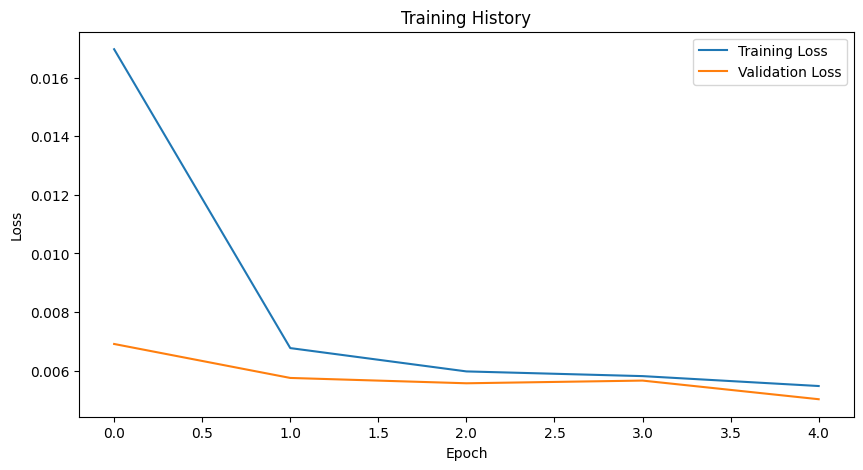

Initial state shape in forward: torch.Size([32, 21, 128, 128]), expected channels: 21
Pred NDVI shape: torch.Size([32, 1, 128, 128])


In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history['train_losses'], label='Training Loss')
plt.plot(history['val_losses'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()
# Run a forward pass and show shapes
# Check if test loader exists and has data
if loader['test']:
    sample_batch = next(iter(loader['test']))
    # Ensure the batch is a dictionary and contains the 'image' key
    if isinstance(sample_batch, dict) and 'image' in sample_batch:
        sample_input_data = sample_batch['image'].to(DEVICE) # Renamed variable
    elif isinstance(sample_batch, (list, tuple)) and len(sample_batch) > 0:
        # Fallback in case the batch structure is different, assuming input data is the first element
        sample_input_data = sample_batch[0].to(DEVICE)
        print("Warning: Assuming input data is the first element in the batch.")
    else:
        print("Could not extract input data tensor from test loader batch.")
        sample_input_data = None

    if sample_input_data is not None:
        final_state = trained_model(sample_input_data, steps=16) # Renamed variable
        pred_ndvi = trained_model.predict_ndvi(final_state)
        print("Pred NDVI shape:", pred_ndvi.shape)
    else:
        print("Skipping forward pass due to issue with test loader batch.")

else:
    print("Skipping training and forward pass because dataloaders were not created successfully.")

In [ ]:
torch.cuda.empty_cache()

# Evaluation

In [49]:
from pathlib import Path

ck_file = Path(OUTPUT_DIR,"checkpoints/20251106_0139-arc_nca-escayard-32-e_5.pth")
# best_ck_files = list(ck_dir.glob("arc_nca-*-e_*.pth
print(f"Loading checkpoint: {ck_file}")
try:
    # load_checkpoint(path, model, optimizer=None, map_location=None)
    load_checkpoint(str(ck_file), model, optimizer=None, map_location=DEVICE)
    model.to(DEVICE)
    model.eval()
    print("Checkpoint loaded, model set to eval()")
except Exception as e:
    print(f"Failed to load checkpoint {ck_file}: {e}")

# Get a random test tile
test_dataset = loader['test'].dataset
sample = test_dataset[np.random.randint(len(test_dataset))]

# Support dict samples (from our VineyardDataset) or tuple/list samples
if isinstance(sample, dict):
    rgb_img = sample['image']        # [C,H,W]
    real_ndvi = sample['target']
elif isinstance(sample, (tuple, list)) and len(sample) >= 2:
    rgb_img, real_ndvi = sample[0], sample[1]
else:
    raise RuntimeError("Unexpected sample format from dataset")

# Ensure batch dimension and move to device
if rgb_img.dim() == 3:
    rgb_img = rgb_img.unsqueeze(0)  # [1,C,H,W]
rgb_img = rgb_img.to(DEVICE)

# Convert target to numpy for visualization/metrics
if isinstance(real_ndvi, torch.Tensor):
    real_ndvi = real_ndvi.cpu().numpy().squeeze()
else:
    real_ndvi = np.array(real_ndvi).squeeze()

with torch.no_grad():
    final_state = model(rgb_img, steps=32)
    pred_ndvi = model.predict_ndvi(final_state).cpu().numpy().squeeze()


Loading checkpoint: ../output/EscaYard/checkpoints/20251106_0139-arc_nca-escayard-32-e_5.pth
Checkpoint loaded, model set to eval()
Initial state shape in forward: torch.Size([1, 21, 128, 128]), expected channels: 21


In [50]:
from sklearn.metrics import r2_score, mean_squared_error
# Flatten arrays for metrics
r2 = r2_score(real_ndvi.flatten(), pred_ndvi.flatten())
rmse = np.sqrt(mean_squared_error(real_ndvi.flatten(), pred_ndvi.flatten()))
print(f"R² = {r2:.4f} | RMSE = {rmse:.4f}")

R² = 0.6645 | RMSE = 0.1102


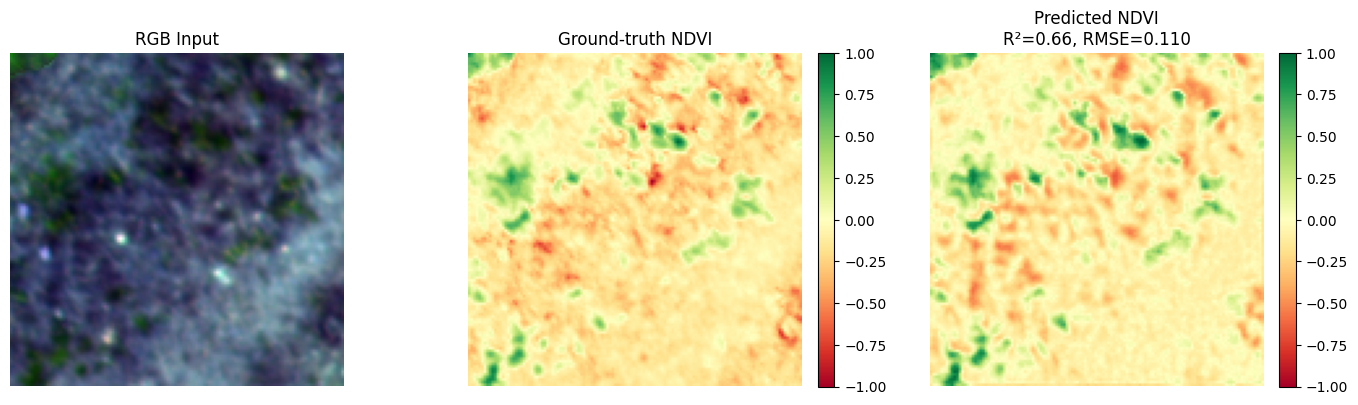

In [53]:
import matplotlib.pyplot as plt
def show_ndvi_comparison(rgb, ndvi_true, ndvi_pred, cmap="RdYlGn"):
    plt.figure(figsize=(14, 4))
    
    # RGB
    plt.subplot(1, 3, 1)
    plt.imshow(np.clip(np.moveaxis(rgb.cpu().numpy(), 0, -1), 0, 1))
    plt.title("RGB Input")
    plt.axis("off")

    # True NDVI
    plt.subplot(1, 3, 2)
    plt.imshow(ndvi_true, cmap=cmap, vmin=-1, vmax=1)
    plt.title("Ground-truth NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    # Predicted NDVI + Residual
    plt.subplot(1, 3, 3)
    plt.imshow(ndvi_pred, cmap=cmap, vmin=-1, vmax=1)
    plt.title(f"Predicted NDVI\nR²={r2:.2f}, RMSE={rmse:.3f}")
    # plt.title(f"Predicted NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ndvi_comparison(rgb_img[0], real_ndvi, pred_ndvi)


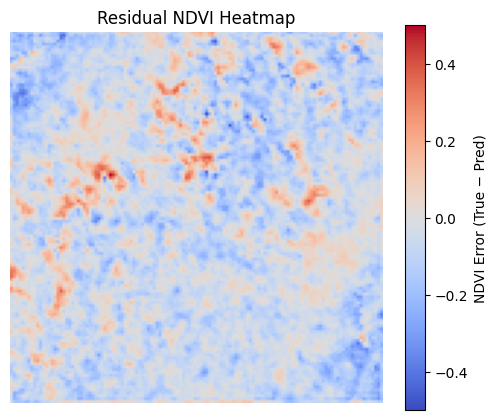

In [54]:
plt.figure(figsize=(6,5))
plt.imshow(real_ndvi - pred_ndvi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.colorbar(label="NDVI Error (True − Pred)")
plt.title("Residual NDVI Heatmap")
plt.axis("off")
plt.show()


In [ ]:
r2_list, rmse_list = [], []
for i in range(len(test_dataset)):
    rgb, ndvi_true = test_dataset[i]
    rgb = rgb.unsqueeze(0).to(DEVICE)
    ndvi_true = ndvi_true.numpy().squeeze()

    with torch.no_grad():
        ndvi_pred = model.predict_ndvi(model(rgb, steps=32)).cpu().numpy().squeeze()

    r2_list.append(r2_score(ndvi_true.flatten(), ndvi_pred.flatten()))
    rmse_list.append(np.sqrt(mean_squared_error(ndvi_true.flatten(), ndvi_pred.flatten())))

print(f"Mean R² = {np.mean(r2_list):.4f}, Mean RMSE = {np.mean(rmse_list):.4f}")

/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


ValueError: too many values to unpack (expected 2)

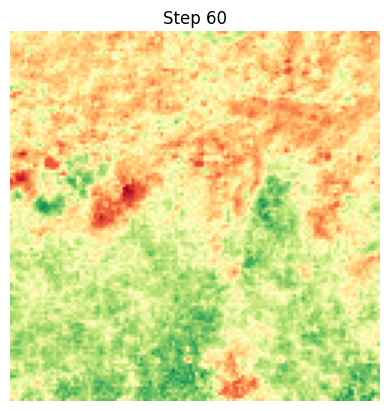

In [ ]:
from IPython.display import clear_output
import time

state = torch.cat([
    rgb_img,
    torch.zeros((1, model.hidden, *rgb_img.shape[2:]), device=DEVICE),
    torch.zeros((1, model.out, *rgb_img.shape[2:]), device=DEVICE),
    torch.ones((1, 1, *rgb_img.shape[2:]), device=DEVICE)
], dim=1)

for step in range(0, 64, 4):
    with torch.no_grad():
        state = model.step(state)
    pred = model.predict_ndvi(state).cpu().numpy().squeeze()
    clear_output(wait=True)
    plt.imshow(pred, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.title(f"Step {step}")
    plt.axis("off")
    plt.show()
    time.sleep(0.2)